# 반덤핑 탐지 분석
## 덤핑 탐지 지표 (Price-based Dumping Detection)
덤핑은 특정 국가가 동일 품목을 다른 시장보다 낮은 가격으로 수출하는 행위이다.

$$DPR_{i,t}^{(p)} = \frac{P^{(p)}_{B \to Kor,t}}{\text{median}(P^{(p)}_{B \to other,t})}$$

$$KPR_{i,t}^{(p)} = \frac{P^{(p)}_{B \to i,t}}{\text{median}(P^{(p)}_{Kor \to other,t})}$$

In [ ]:
# 패키지 설치
!pip install comtradeapicall -q

In [2]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import re
import time
import requests
import xml.etree.ElementTree as ET
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import comtradeapicall

pd.set_option('display.max_columns', None)

# ── 설정 ──────────────────────────────────────────────────
BASE_DIR = '/content/drive/MyDrive/무통대첩'  # ← 필요시 경로 수정

from google.colab import userdata
Un_Comtrade_API_KEY = userdata.get("UN_COMTRADE_API_KEY")
GW_API_KEY = userdata.get("GW_API_KEY")

KOREA_CODE = 410

In [23]:
# ── 헬퍼 함수 ─────────────────────────────────────────────

def clean_hs_code(raw: str) -> str:
    cleaned = re.sub(r'[.\-\s]', '', str(raw).strip())
    cleaned = re.sub(r'[^\d]', '', cleaned)
    return cleaned[:6].ljust(6, '0')


def make_period_pm_1year(date_str: str) -> str:
    dt    = pd.to_datetime(date_str)
    start = dt - pd.DateOffset(years=1)
    end   = dt + pd.DateOffset(years=1)
    return f"{start.strftime('%Y%m')}~{end.strftime('%Y%m')}"


def split_country_names(country_str: str) -> list:
    parts = re.split(r'[,，/；;]|(?:\s*(?:및|과|and)\s*)', country_str)
    return [p.strip() for p in parts if p.strip()]

In [24]:
# ── UN Comtrade 래퍼 ──────────────────────────────────────

def Un_Comtrade(
    api_key, reporter_code, partner_code, cmd_code, period,
    flow_code='X', freq_code='A', type_code='C', cl_code='HS',
    max_records=2500, columns=None, include_desc=True, verbose=True
):
    def parse_period_input(period_str):
        period_str = str(period_str).strip()
        if '~' not in period_str:
            return [p.strip() for p in period_str.split(',') if p.strip()]
        start, end = [x.strip() for x in period_str.split('~', 1)]
        if len(start) == 4 and len(end) == 4:
            start_y, end_y = int(start), int(end)
            if start_y > end_y:
                raise ValueError('시작 연도가 종료 연도보다 큽니다.')
            return [str(y) for y in range(start_y, end_y + 1)]
        if len(start) == 6 and len(end) == 6:
            start_y, start_m = int(start[:4]), int(start[4:])
            end_y,   end_m   = int(end[:4]),   int(end[4:])
            if not (1 <= start_m <= 12 and 1 <= end_m <= 12):
                raise ValueError('월은 01~12여야 합니다.')
            if (start_y, start_m) > (end_y, end_m):
                raise ValueError('시작 기간이 종료 기간보다 큽니다.')
            result, y, m = [], start_y, start_m
            while (y < end_y) or (y == end_y and m <= end_m):
                result.append(f'{y}{m:02d}')
                m += 1
                if m > 12:
                    m, y = 1, y + 1
            return result
        raise ValueError("period 형식은 '2020~2024' 또는 '202001~202012'처럼 입력해야 합니다.")

    def chunk_periods(period_list, chunk_size=12):
        return [period_list[i:i + chunk_size] for i in range(0, len(period_list), chunk_size)]

    period_list   = parse_period_input(period)
    period_chunks = chunk_periods(period_list, chunk_size=12)
    frames        = []

    for i, chunk in enumerate(period_chunks, start=1):
        chunk_period = ','.join(chunk)
        if verbose:
            print(f'[{i}/{len(period_chunks)}] 호출 중: period={chunk_period}')
        df_part = comtradeapicall.getFinalData(
            api_key, typeCode=type_code, freqCode=freq_code, clCode=cl_code,
            period=chunk_period, reporterCode=str(reporter_code), cmdCode=str(cmd_code),
            flowCode=flow_code, partnerCode=None if partner_code is None else str(partner_code),
            partner2Code=None, customsCode=None, motCode=None, maxRecords=max_records,
            format_output='JSON', aggregateBy=None, breakdownMode='classic',
            countOnly=None, includeDesc=include_desc
        )
        if df_part is None or not isinstance(df_part, pd.DataFrame) or df_part.empty:
            continue
        df_part = df_part.dropna(axis=0, how='all').dropna(axis=1, how='all')
        if df_part.empty or df_part.shape[1] == 0:
            continue
        frames.append(df_part)

    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True).drop_duplicates().reset_index(drop=True)
    if columns is not None:
        missing = [c for c in columns if c not in df.columns]
        if missing:
            raise ValueError(f'존재하지 않는 컬럼: {missing}')
        df = df[columns].copy()
    return df

In [34]:
# ── 공공데이터포털 (GW) 래퍼 ──────────────────────────────

def GW(
    service_key, start, end, hs_code, country,
    trade_type='all', columns=None, rename_map=None, exclude_total=True
):
    trade_type = trade_type.lower()
    if trade_type not in {'all','전체','export','exp','수출','import','imp','수입'}:
        raise ValueError("trade_type은 'all','export','import','전체','수출','수입' 중 하나여야 합니다.")

    hs_code = str(hs_code)
    hs_len  = len(hs_code)
    if hs_len not in {2, 4, 6, 10}:
        raise ValueError('hs_code는 2/4/6/10단위 코드로 넣어주세요.')

    if columns is None:
        columns = ['year','statCdCntnKor1','statCd','statKor','hsCd',
                   'impDlr','expDlr','impWgt','expWgt','balPayments']
    if rename_map is None:
        rename_map = {}

    url = "https://apis.data.go.kr/1220000/Itemtrade/getItemtradeList"
    numeric_columns = {'impDlr','expDlr','impWgt','expWgt','balPayments'}

    def validate_yymm(yymm):
        try:
            datetime.strptime(yymm, '%Y%m')
        except ValueError as e:
            raise ValueError(f'날짜 형식 오류: {yymm}. YYYYMM 형식으로 입력하세요.') from e

    def add_months(dt, months):
        year  = dt.year + (dt.month - 1 + months) // 12
        month = (dt.month - 1 + months) % 12 + 1
        return dt.replace(year=year, month=month)

    def split_period(start_yymm, end_yymm):
        periods, current_start = [], datetime.strptime(start_yymm, '%Y%m')
        end_dt = datetime.strptime(end_yymm, '%Y%m')
        while current_start <= end_dt:
            current_end = min(add_months(current_start, 11), end_dt)
            periods.append((current_start.strftime('%Y%m'), current_end.strftime('%Y%m')))
            current_start = add_months(current_end, 1)
        return periods

    validate_yymm(start)
    validate_yymm(end)
    if datetime.strptime(start, '%Y%m') > datetime.strptime(end, '%Y%m'):
        raise ValueError('start는 end보다 클 수 없습니다.')

    all_rows = []
    for s, e in split_period(start, end):
        params = {'serviceKey': service_key, 'strtYymm': s, 'endYymm': e,
                  'hsSgn': hs_code, 'cntyCd': country}
        res = requests.get(url, params=params, timeout=30)
        if res.status_code != 200:
            raise RuntimeError(f'HTTP 오류: {res.status_code}\n{res.text[:300]}')
        try:
            root = ET.fromstring(res.text)
        except ET.ParseError as err:
            raise RuntimeError(f'XML 파싱 실패.\n{res.text[:300]}') from err
        result_code = root.findtext('./header/resultCode')
        if result_code != '00':
            raise RuntimeError(f"API 오류: {root.findtext('./header/resultMsg')}")
        for item in root.findall('./body/items/item'):
            if exclude_total and item.findtext('year') == '총계':
                continue
            row = {}
            for col in columns:
                value = item.findtext(col)
                if col in numeric_columns and value not in (None, '', '-'):
                    try:
                        value = int(value)
                    except ValueError:
                        pass
                row[col] = value
            all_rows.append(row)

    df = pd.DataFrame(all_rows)
    if df.empty:
        return df.rename(columns=rename_map) if rename_map else df

    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

    if trade_type in {'export','exp','수출'}:
        df = df[(df['expDlr'] != 0) | (df['expWgt'] != 0)].copy()
    elif trade_type in {'import','imp','수입'}:
        df = df[(df['impDlr'] != 0) | (df['impWgt'] != 0)].copy()

    if df.empty:
        return df.rename(columns=rename_map) if rename_map else df

    df['hsCd']   = df['hsCd'].astype(str).str[:hs_len]
    group_cols   = [c for c in ['year','statCdCntnKor1','statCd','hsCd'] if c in df.columns]
    agg_dict     = {c: 'sum' for c in numeric_columns if c in df.columns}
    if 'statKor' in df.columns:
        agg_dict['statKor'] = 'first'

    df = df.groupby(group_cols, as_index=False).agg(agg_dict)
    if 'statKor' in df.columns:
        df['statKor'] = 'HS ' + df['hsCd'].astype(str)

    ordered_cols = ['year','statCdCntnKor1','statCd','statKor','hsCd',
                    'impDlr','expDlr','impWgt','expWgt','balPayments']
    df = df[[c for c in ordered_cols if c in df.columns]]
    return df.rename(columns=rename_map) if rename_map else df

In [35]:
# ── 단가 / DPR / KPR ──────────────────────────────────────

def _add_unit_price(df, value_col='primaryValue', quantity_col='qty'):
    df = df.copy()
    df[value_col]    = pd.to_numeric(df[value_col],    errors='coerce')
    df[quantity_col] = pd.to_numeric(df[quantity_col], errors='coerce')
    df['P'] = df[value_col] / df[quantity_col]
    return df.replace([np.inf, -np.inf], np.nan)


def _remove_aggregate_partners(df, partner_col='partnerCode'):
    df = df.copy()
    return df[~df[partner_col].astype(str).isin({'0', '999'})].copy()


def get_trade_data(
    api_key, reporter_code, partner_code, cmd_code, period,
    flow_code='X', freq_code='M', verbose=True
):
    if '~' in period:
        start_str, end_str = [p.strip() for p in period.split('~')]
        start_dt = datetime.strptime(start_str, '%Y%m')
        end_dt   = datetime.strptime(end_str,   '%Y%m')
        months, cur = [], start_dt
        while cur <= end_dt:
            months.append(cur.strftime('%Y%m'))
            m, y = cur.month + 1, cur.year
            if m > 12:
                m, y = 1, y + 1
            cur = cur.replace(year=y, month=m)
    else:
        months = [m.strip() for m in period.split(',')]

    url     = f'https://comtradeapi.un.org/data/v1/get/C/{freq_code}/HS'
    headers = {'Ocp-Apim-Subscription-Key': api_key.strip()}
    all_dfs = []

    for i in range(0, len(months), 12):
        chunk      = months[i:i + 12]
        period_str = ','.join(chunk)
        params     = {'reporterCode': str(reporter_code), 'cmdCode': str(cmd_code),
                      'flowCode': flow_code, 'period': period_str, 'includeDesc': 'true'}
        if partner_code is not None:
            params['partnerCode'] = str(partner_code)
        if verbose:
            print(f'  Fetching reporter={reporter_code}, partner={partner_code}, period={period_str}')
        resp = requests.get(url, params=params, headers=headers, timeout=30)
        if resp.status_code == 429:
            if verbose:
                print('  Rate limited — 60초 대기 중...')
            time.sleep(60)
            resp = requests.get(url, params=params, headers=headers, timeout=30)
        if resp.status_code != 200:
            raise RuntimeError(f'HTTP 오류 {resp.status_code}\n{resp.text[:300]}')
        data = resp.json()
        if data.get('data'):
            all_dfs.append(pd.DataFrame(data['data']))
        time.sleep(1)

    if not all_dfs:
        return pd.DataFrame()
    return pd.concat(all_dfs, ignore_index=True)


def calc_monthly_dpr(api_key, exporter_code, korea_code, cmd_code, period,
                     value_col='primaryValue', quantity_col='qty', verbose=True):
    df_b_kr    = get_trade_data(api_key, exporter_code, korea_code, cmd_code, period,
                                flow_code='X', freq_code='M', verbose=verbose)
    df_b_world = get_trade_data(api_key, exporter_code, None,       cmd_code, period,
                                flow_code='X', freq_code='M', verbose=verbose)
    if df_b_kr.empty or df_b_world.empty:
        return pd.DataFrame()
    df_b_kr    = _add_unit_price(df_b_kr,    value_col, quantity_col)
    df_b_world = _add_unit_price(df_b_world, value_col, quantity_col)
    df_b_kr['period']    = df_b_kr['period'].astype(str)
    df_b_world['period'] = df_b_world['period'].astype(str)
    monthly_kr    = df_b_kr.groupby('period', as_index=False).agg(
        P_B_to_KR=('P','median'), Value_B_to_KR=(value_col,'sum'), Quantity_B_to_KR=(quantity_col,'sum'))
    df_other      = _remove_aggregate_partners(df_b_world)
    df_other      = df_other[df_other['partnerCode'].astype(str) != str(korea_code)].copy()
    monthly_other = df_other.groupby('period', as_index=False).agg(median_P_B_to_other=('P','median'))
    result = monthly_kr.merge(monthly_other, on='period', how='left')
    result['DPR'] = result['P_B_to_KR'] / result['median_P_B_to_other']
    result['exporterCode'] = exporter_code
    result['koreaCode']    = korea_code
    result['cmdCode']      = cmd_code
    return result.replace([np.inf, -np.inf], np.nan).sort_values('period').reset_index(drop=True)


def calc_monthly_kpr(api_key, exporter_code, korea_code, cmd_code, period,
                     value_col='primaryValue', quantity_col='qty', verbose=True):
    df_b_kr     = get_trade_data(api_key, exporter_code, korea_code, cmd_code, period,
                                 flow_code='X', freq_code='M', verbose=verbose)
    df_kr_world = get_trade_data(api_key, korea_code,    None,       cmd_code, period,
                                 flow_code='X', freq_code='M', verbose=verbose)
    if df_b_kr.empty or df_kr_world.empty:
        return pd.DataFrame()
    df_b_kr     = _add_unit_price(df_b_kr,     value_col, quantity_col)
    df_kr_world = _add_unit_price(df_kr_world, value_col, quantity_col)
    df_b_kr['period']     = df_b_kr['period'].astype(str)
    df_kr_world['period'] = df_kr_world['period'].astype(str)
    monthly_import  = df_b_kr.groupby('period', as_index=False).agg(
        P_B_to_KR=('P','median'), Value_B_to_KR=(value_col,'sum'), Quantity_B_to_KR=(quantity_col,'sum'))
    df_kr_world     = _remove_aggregate_partners(df_kr_world)
    monthly_kor_exp = df_kr_world.groupby('period', as_index=False).agg(median_P_KR_to_World=('P','median'))
    result = monthly_import.merge(monthly_kor_exp, on='period', how='left')
    result['KPR'] = result['P_B_to_KR'] / result['median_P_KR_to_World']
    result['exporterCode'] = exporter_code
    result['koreaCode']    = korea_code
    result['cmdCode']      = cmd_code
    return result.replace([np.inf, -np.inf], np.nan).sort_values('period').reset_index(drop=True)

In [36]:
# ── 반덤핑 관세 데이터 로드 ────────────────────────────────
import os

tariff_path = os.path.join(BASE_DIR, 'Antidumping_Traff.csv')
tariff_df   = pd.read_csv(tariff_path, encoding='cp949')
tariff_df   = tariff_df[tariff_df.columns[0:6]]
tariff_df

,국가명,품목,HS코드(cmd),관세부과범위,부과시작일,부과종료일
0,"중국,싱가포르,일본",초산에틸(1차재심),2915.31,3.14~14.17,2012-03-27,2015-03-26
1,"중국,인도",PET필름(1차재심),3920.62,5.87~25.32,2012-05-25,2015-05-24
2,"러시아,미국캐나다,중국,인도네시아",크라프트지(1차재심),4804.00,4.03~10.79,2012-04-10,2015-04-09
3,"대만,중국",폴리에스터 장섬유 부분연신사(1차재심),5402.46,6.26,2012-07-25,2014-07-24
4,일본,알루미늄 보틀캔,7612.90,4.59,2013-01-03,2016-01-02
5,"미국,인도,중국,캐나다",염화콜린(2차재심),2923.10,22.19~27.32,2013-08-22,2016-08-21
6,"일본,인도,스페인",스테인레스스틸바(2차재심),7222.00,)2.76~15.39,2013-10-01,2016-09-30
7,중국,합판,4412.00,2.42~27.21,2013-10-18,2016-10-17
8,"중국,대만,말레이시아",폴리에스테르 장섬유 연신가공사(2차재심),5402.00,8.69~2.22,2013-12-20,2016-12-19
9,"중국,인도네시아,태국",OPP필름,3920.20,3.48~25.04,2013-12-20,2018-12-19


In [37]:
# ── 행별 DPR / KPR 분석 함수 ──────────────────────────────

COUNTRY_CODE_MAP = {
    '중국': 156, '미국': 840, '일본': 392, '베트남': 704,
    '독일': 276, '인도': 356, '대만': 158, '태국': 764,
    '말레이시아': 458, '인도네시아': 360, '튀르키예': 792,
    '터키': 792, '러시아': 643, '브라질': 76, '캐나다': 124,
    '호주': 36, '영국': 826, '프랑스': 250, '이탈리아': 380,
    '스페인': 724, '멕시코': 484,
}


def analyze_tariff_row(
    tariff_df, row_idx, UN_api_key,
    gw_service_key=None, korea_code=KOREA_CODE,
    value_col='primaryValue', quantity_col='netWgt',
    hs_level=6, verbose=False, plot=True
):
    def add_price(df):
        df = df.copy()
        df[value_col]    = pd.to_numeric(df[value_col],    errors='coerce')
        df[quantity_col] = pd.to_numeric(df[quantity_col], errors='coerce')
        df['P'] = df[value_col] / df[quantity_col]
        return df.replace([np.inf, -np.inf], np.nan)

    def remove_aggregate(df):
        df = df.copy()
        if 'partnerCode' in df.columns:
            df = df[~df['partnerCode'].astype(str).isin(['0', '999'])].copy()
        return df

    def normalize_period(s):
        return (s.astype(str)
                 .str.replace('.', '', regex=False)
                 .str.replace('-', '', regex=False)
                 .str[:6])

    def get_kor_export_price_from_gw(start, end, hs_code):
        if gw_service_key is None:
            return pd.DataFrame()
        df_gw = GW(service_key=gw_service_key, start=start, end=end,
                   hs_code=hs_code, country=None, trade_type='exp')
        if df_gw.empty:
            return pd.DataFrame()
        df_gw = df_gw.copy()
        df_gw['expDlr'] = pd.to_numeric(df_gw['expDlr'], errors='coerce')
        df_gw['expWgt'] = pd.to_numeric(df_gw['expWgt'], errors='coerce')
        df_gw = df_gw[df_gw['expDlr'].notna() & df_gw['expWgt'].notna() & (df_gw['expWgt'] > 0)].copy()
        if df_gw.empty:
            return pd.DataFrame()
        df_gw['P_KR_to_World'] = df_gw['expDlr'] / df_gw['expWgt']
        df_gw['period']        = normalize_period(df_gw['year'])
        return df_gw.groupby('period', as_index=False).agg(median_P_KR_to_World=('P_KR_to_World','median'))

    row       = tariff_df.loc[row_idx]
    hs_code_6 = clean_hs_code(row['HS코드(cmd)'])
    hs_code   = hs_code_6 if hs_level == 6 else hs_code_6[:4] if hs_level == 4 else None
    if hs_code is None:
        raise ValueError('hs_level은 6 또는 4만 가능합니다.')

    period     = make_period_pm_1year(row['부과시작일'])
    start, end = period.split('~')
    countries  = split_country_names(row['국가명'])

    print(f"품목: {row['품목']}")
    print(f"원 HS코드: {hs_code_6}")
    print(f"분석 HS코드: {hs_code} ({hs_level}단위)")
    print(f"분석기간: {period}")
    print(f"대상국가: {countries}")

    result_list = []
    for country in countries:
        if country not in COUNTRY_CODE_MAP:
            print(f'[스킵] 국가 코드 없음: {country}')
            continue
        exporter_code = COUNTRY_CODE_MAP[country]
        print(f'분석 중: {country} ({exporter_code})')

        df_b_kr     = Un_Comtrade(UN_api_key, exporter_code, korea_code,
                                  hs_code, period, flow_code='X', freq_code='M', verbose=verbose)
        df_b_world  = Un_Comtrade(UN_api_key, exporter_code, None,
                                  hs_code, period, flow_code='X', freq_code='M', verbose=verbose)
        df_kr_world = Un_Comtrade(UN_api_key, korea_code, None,
                                  hs_code, period, flow_code='X', freq_code='M', verbose=verbose)

        if df_b_kr.empty or df_b_world.empty:
            print(f'[DPR 계산 불가] {country}, HS {hs_code}')
            continue

        df_b_kr    = add_price(df_b_kr)
        df_b_world = add_price(df_b_world)
        df_b_kr['period']    = normalize_period(df_b_kr['period'])
        df_b_world['period'] = normalize_period(df_b_world['period'])

        monthly_b_kr = df_b_kr.groupby('period', as_index=False).agg(
            P_B_to_KR=('P','median'), Value_B_to_KR=(value_col,'sum'), Quantity_B_to_KR=(quantity_col,'sum'))
        df_other = remove_aggregate(df_b_world)
        if 'partnerCode' in df_other.columns:
            df_other = df_other[df_other['partnerCode'].astype(str) != str(korea_code)].copy()
        monthly_b_other = df_other.groupby('period', as_index=False).agg(median_P_B_to_other=('P','median'))

        df_result = monthly_b_kr.merge(monthly_b_other, on='period', how='left')
        df_result['DPR'] = df_result['P_B_to_KR'] / df_result['median_P_B_to_other']

        monthly_kr_world = pd.DataFrame()
        if not df_kr_world.empty:
            df_kr_world = add_price(df_kr_world)
            df_kr_world['period'] = normalize_period(df_kr_world['period'])
            df_kr_world = remove_aggregate(df_kr_world)
            monthly_kr_world = df_kr_world.groupby('period', as_index=False).agg(
                median_P_KR_to_World=('P','median'))

        un_kpr_valid = (
            not monthly_kr_world.empty
            and monthly_kr_world['median_P_KR_to_World']
                .replace([np.inf, -np.inf], np.nan).dropna().gt(0).any()
        )
        if not un_kpr_valid:
            print(f'[KPR UN 없음 → GW로 대체] {country}, HS {hs_code}')
            monthly_kr_world = get_kor_export_price_from_gw(start, end, hs_code)

        if monthly_kr_world.empty:
            df_result['median_P_KR_to_World'] = pd.NA
            df_result['KPR']                  = pd.NA
        else:
            df_result = df_result.merge(
                monthly_kr_world[['period','median_P_KR_to_World']], on='period', how='left')
            df_result['KPR'] = df_result['P_B_to_KR'] / df_result['median_P_KR_to_World']

        df_result = df_result.replace([np.inf, -np.inf], np.nan).sort_values('period').reset_index(drop=True)
        df_result['country']           = country
        df_result['exporterCode']      = exporter_code
        df_result['koreaCode']         = korea_code
        df_result['cmdCode']           = hs_code
        df_result['product']           = row['품목']
        df_result['hs_code_original']  = hs_code_6
        df_result['hs_code_used']      = hs_code
        df_result['hs_level']          = hs_level
        df_result['tariff_start_date'] = row['부과시작일']
        df_result['tariff_end_date']   = row['부과종료일']
        result_list.append(df_result)

    if not result_list:
        return pd.DataFrame()

    final_df = pd.concat(result_list, ignore_index=True)

    if plot:
        plt.rcParams['font.family']        = 'NanumGothic'  # 코랩 한글 폰트
        plt.rcParams['axes.unicode_minus'] = False
        tariff_period = pd.to_datetime(row['부과시작일']).strftime('%Y%m')
        periods = sorted(final_df['period'].unique())
        x_map   = {p: i for i, p in enumerate(periods)}
        plt.figure(figsize=(15, 6))
        for country, g in final_df.groupby('country'):
            g = g.sort_values('period').copy()
            g['x'] = g['period'].map(x_map)
            if g['DPR'].notna().any():
                plt.plot(g['x'], g['DPR'], marker='o', label=f'DPR-{country}')
            if g['KPR'].notna().any():
                plt.plot(g['x'], g['KPR'], marker='s', linestyle='--', label=f'KPR-{country}')
        plt.axhline(1, linestyle='--', linewidth=1, label='Ratio = 1')
        if tariff_period in x_map:
            plt.axvline(x=x_map[tariff_period], linestyle=':', linewidth=2, label='Tariff Start')
        plt.title(f"HS {hs_code} ({hs_level}단위) | {row['품목']} | DPR & KPR")
        plt.xlabel('Period')
        plt.ylabel('Ratio')
        plt.xticks(range(len(periods)), periods, rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return final_df

In [38]:
# ── 코랩 한글 폰트 설치 (그래프 한글 깨짐 방지) ────────────
!apt-get install -y fonts-nanum -q
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
print('한글 폰트 설치 완료 — 런타임 재시작 없이 바로 사용 가능')

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
한글 폰트 설치 완료 — 런타임 재시작 없이 바로 사용 가능


품목: PET필름(1차재심)
원 HS코드: 392062
분석 HS코드: 392062 (6단위)
분석기간: 201105~201305
대상국가: ['중국', '인도']
분석 중: 중국 (156)
[KPR UN 없음 → GW로 대체] 중국, HS 392062
분석 중: 인도 (356)


/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.t

[DPR 계산 불가] 인도, HS 392062


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


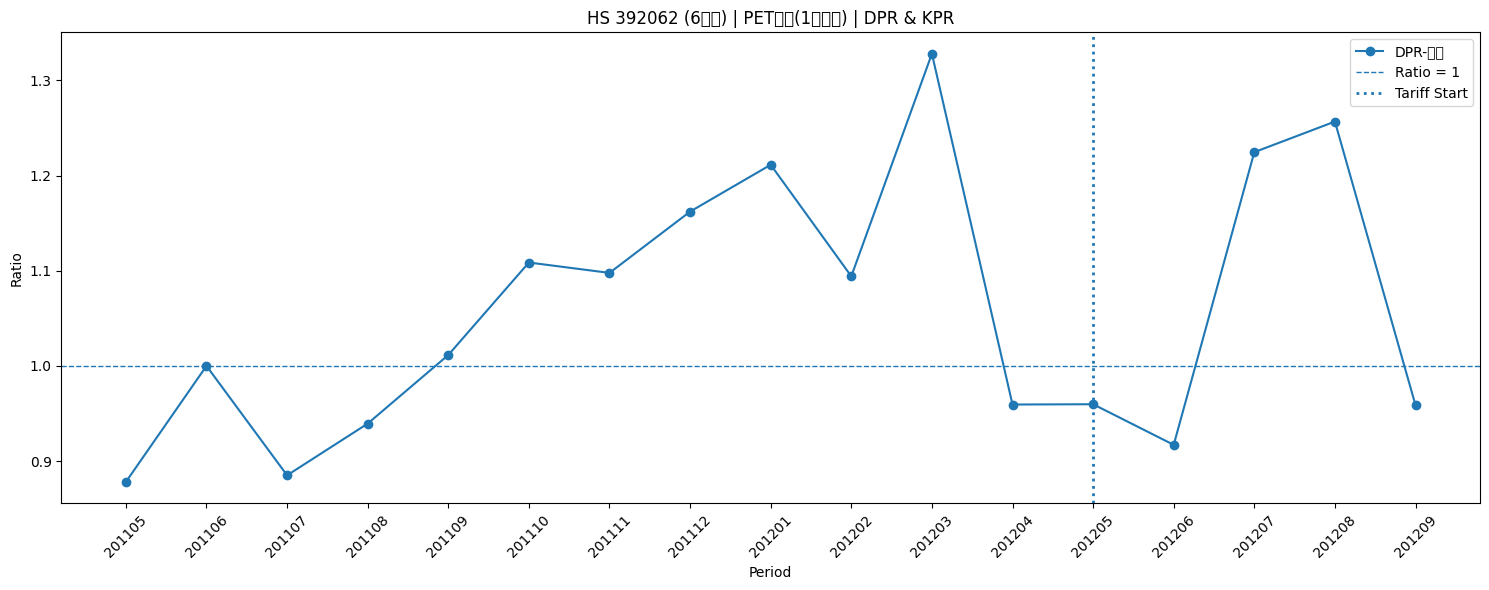

,period,P_B_to_KR,Value_B_to_KR,Quantity_B_to_KR,median_P_B_to_other,DPR,median_P_KR_to_World,KPR,country,exporterCode,koreaCode,cmdCode,product,hs_code_original,hs_code_used,hs_level,tariff_start_date,tariff_end_date
0,201105,3.147702,1665062.0,528977.0,3.584356,0.878178,<NA>,<NA>,중국,156,410,392062,PET필름(1차재심),392062,392062,6,2012-05-25,2015-05-24
1,201106,3.469675,1310479.0,377695.0,3.469559,1.000034,<NA>,<NA>,중국,156,410,392062,PET필름(1차재심),392062,392062,6,2012-05-25,2015-05-24
2,201107,3.109690,1244610.0,400236.0,3.513297,0.885120,<NA>,<NA>,중국,156,410,392062,PET필름(1차재심),392062,392062,6,2012-05-25,2015-05-24
3,201108,3.241696,1359590.0,419407.0,3.450610,0.939456,<NA>,<NA>,중국,156,410,392062,PET필름(1차재심),392062,392062,6,2012-05-25,2015-05-24
4,201109,3.606916,1151223.0,319171.0,3.565862,1.011513,<NA>,<NA>,중국,156,410,392062,PET필름(1차재심),392062,392062,6,2012-05-25,2015-05-24
5,201110,4.208123,759461.0,180475.0,3.795724,1.108648,<NA>,<NA>,중국,156,410,392062,PET필름(1차재심),392062,392062,6,2012-05-25,2015-05-24
6,201111,3.884062,905841.0,233220.0,3.538227,1.097742,<NA>,<NA>,중국,156,410,392062,PET필름(1차재심),392062,392062,6,2012-05-25,2015-05-24
7,201112,3.854836,909699.0,235989.0,3.317052,1.162127,<NA>,<NA>,중국,156,410,392062,PET필름(1차재심),392062,392062,6,2012-05-25,2015-05-24
8,201201,4.232145,726181.0,171587.0,3.493812,1.211326,<NA>,<NA>,중국,156,410,392062,PET필름(1차재심),392062,392062,6,2012-05-25,2015-05-24
9,201202,3.896168,679106.0,174301.0,3.560863,1.094164,<NA>,<NA>,중국,156,410,392062,PET필름(1차재심),392062,392062,6,2012-05-25,2015-05-24


In [39]:
# ── 실행: row_idx=1 ────────────────────────────────────────
result1 = analyze_tariff_row(
    tariff_df=tariff_df,
    row_idx=1,
    UN_api_key=Un_Comtrade_API_KEY,
    gw_service_key=GW_API_KEY,
    hs_level=6,
    plot=True
)
result1

품목: PET필름(1차재심)
원 HS코드: 392062
분석 HS코드: 3920 (4단위)
분석기간: 201105~201305
대상국가: ['중국', '인도']
분석 중: 중국 (156)
[1/3] 호출 중: period=201105,201106,201107,201108,201109,201110,201111,201112,201201,201202,201203,201204
[2/3] 호출 중: period=201205,201206,201207,201208,201209,201210,201211,201212,201301,201302,201303,201304
[3/3] 호출 중: period=201305
[1/3] 호출 중: period=201105,201106,201107,201108,201109,201110,201111,201112,201201,201202,201203,201204
[2/3] 호출 중: period=201205,201206,201207,201208,201209,201210,201211,201212,201301,201302,201303,201304
[3/3] 호출 중: period=201305
[1/3] 호출 중: period=201105,201106,201107,201108,201109,201110,201111,201112,201201,201202,201203,201204
[2/3] 호출 중: period=201205,201206,201207,201208,201209,201210,201211,201212,201301,201302,201303,201304
[3/3] 호출 중: period=201305
[KPR UN 없음 → GW로 대체] 중국, HS 3920
분석 중: 인도 (356)
[1/3] 호출 중: period=201105,201106,201107,201108,201109,201110,201111,201112,201201,201202,201203,201204
[2/3] 호출 중: period=201205,201206,201207,201208,2

/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20402/785513341.py:170: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.t

[DPR 계산 불가] 인도, HS 3920


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


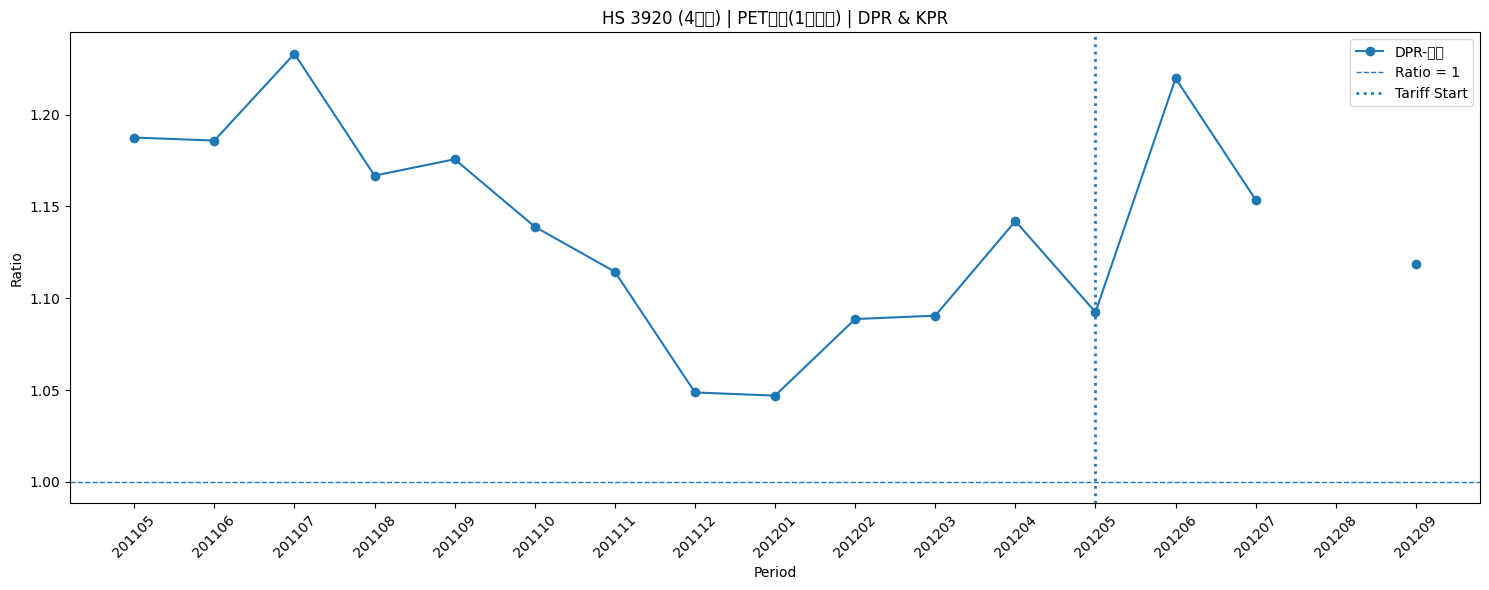

In [45]:
result1 = analyze_tariff_row(
    tariff_df=tariff_df,
    row_idx=1,
    UN_api_key=Un_Comtrade_API_KEY,
    gw_service_key=None,
    hs_level=4,          # ← 이거 추가
    verbose=True,
)

In [47]:
import json

# 기본 정보
row = tariff_df.iloc[1]
print("=== 사건 정보 ===")
print(row.to_string())

# DPR/KPR 요약
print("\n=== DPR/KPR 요약 ===")
print(result1.to_string())

# 통계
print("\n=== 기술통계 ===")
cols = [c for c in result1.columns if c in ['DPR', 'KPR']]
print(result1[cols].describe().to_string())

=== 사건 정보 ===
국가명                중국,인도
품목           PET필름(1차재심)
HS코드(cmd)        3920.62
관세부과범위        5.87~25.32
부과시작일         2012-05-25
부과종료일         2015-05-24

=== DPR/KPR 요약 ===
    period  P_B_to_KR  Value_B_to_KR  Quantity_B_to_KR  median_P_B_to_other       DPR median_P_KR_to_World   KPR country  exporterCode  koreaCode cmdCode      product hs_code_original hs_code_used  hs_level tariff_start_date tariff_end_date
0   201105   3.144113     15746917.0         5008381.0             2.647607  1.187530                 <NA>  <NA>      중국           156        410    3920  PET필름(1차재심)           392062         3920         4        2012-05-25      2015-05-24
1   201106   3.183931     15930571.0         5003428.0             2.684836  1.185894                 <NA>  <NA>      중국           156        410    3920  PET필름(1차재심)           392062         3920         4        2012-05-25      2015-05-24
2   201107   3.282422     15360254.0         4679549.0             2.661788  1.233164        